# Logistic regression for trading - S&P 500

In [257]:
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, make_scorer,
)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

## 1. Data

In [258]:
def download(ticker, start="2015-01-01"):
    raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    return raw

In [259]:
ticker = "^GSPC"
df = download(ticker)[["Open", "High", "Low", "Close"]].copy()
df.tail()

Price,Open,High,Low,Close
Date,,,,
2026-07-29,7418.160156,7450.839844,7313.919922,7316.149902
2026-07-30,7390.450195,7448.750000,7370.979980,7437.629883
2026-07-31,7462.129883,7512.040039,7399.830078,7489.720215
2026-08-03,7504.779785,7610.040039,7504.779785,7600.500000
2026-08-04,7630.620117,7754.490234,7629.100098,7747.319824


## 2. Feature engineering

Six features, computed with TA-Lib where a direct indicator exists: trend strength, mean-reversion position, volatility level, candle anatomy, and prior return magnitude. This set is the result of a collinearity pass (section 3) that removed five originally-considered features (`rsi`, `momentum`, `dist_ma_atr`, `return_zscore`, `distance_from_n_day_low`) for being redundant with the ones kept.

In [260]:
adx_period = 14
bb_period = 20
bb_std = 2
atr_period = 14

In [261]:
def build_features(raw):
    d = raw[["Open", "High", "Low", "Close"]].copy()

    d["atr"] = talib.ATR(d["High"], d["Low"], d["Close"], timeperiod=atr_period)
    d["adx"] = talib.ADX(d["High"], d["Low"], d["Close"], timeperiod=adx_period)

    bb_upper, bb_mid, bb_lower = talib.BBANDS(d["Close"], timeperiod=bb_period, nbdevup=bb_std, nbdevdn=bb_std)
    d["bb_pct"] = (d["Close"] - bb_mid) / (bb_upper - bb_lower)

    # Volatility normalized by price
    d["atr_norm"] = d["atr"] / d["Close"]

    # Candle anatomy
    high_low_range = (d["High"] - d["Low"]).replace(0, np.nan)
    d["body_ratio"] = (d["Close"] - d["Open"]).abs() / high_low_range
    d["lower_wick_ratio"] = (d[["Open", "Close"]].min(axis=1) - d["Low"]) / high_low_range

    # Return magnitude, in ATR units
    d["prev_return_atr"] = (d["Close"] - d["Close"].shift(1)) / d["atr"]

    return d.iloc[60:].copy()  # warmup buffer


feature_cols = ["adx", "bb_pct", "atr_norm", "body_ratio", "lower_wick_ratio", "prev_return_atr"]

In [262]:
df = build_features(df)
df.tail()

Price,Open,High,Low,Close,atr,adx,bb_pct,atr_norm,body_ratio,lower_wick_ratio,prev_return_atr
Date,,,,,,,,,,,
2026-07-29,7418.160156,7450.839844,7313.919922,7316.149902,84.182318,16.198096,-0.658575,0.011506,0.745036,0.016287,-1.337928
2026-07-30,7390.450195,7448.750000,7370.979980,7437.629883,87.640730,17.323213,-0.168344,0.011783,0.606656,0.250356,1.386113
2026-07-31,7462.129883,7512.040039,7399.830078,7489.720215,89.395675,17.098471,0.033388,0.011936,0.245881,0.555207,0.582694
2026-08-03,7504.779785,7610.040039,7504.779785,7600.500000,91.604543,16.360338,0.425432,0.012052,0.909367,0.000000,1.209326
2026-08-04,7630.620117,7754.490234,7629.100098,7747.319824,96.060664,17.176630,0.703154,0.012399,0.930693,0.012122,1.528407


`bb_pct` here is `(close - bb_mid) / (bb_upper - bb_lower)` — distance from the **middle** band
normalized by band width, centered at 0 (not the standard %B, which uses the lower band and is centered at
0.5).

## 3. Collinearity check

Two complementary views: a correlation matrix (pairwise relationships only) and VIF (how well each feature is predicted by *all* the others combined). A feature can look fine pairwise — no single correlation stands out — while still being almost fully explained by a combination of two or three others; VIF catches that, a correlation matrix alone doesn't.

### Correlation matrix

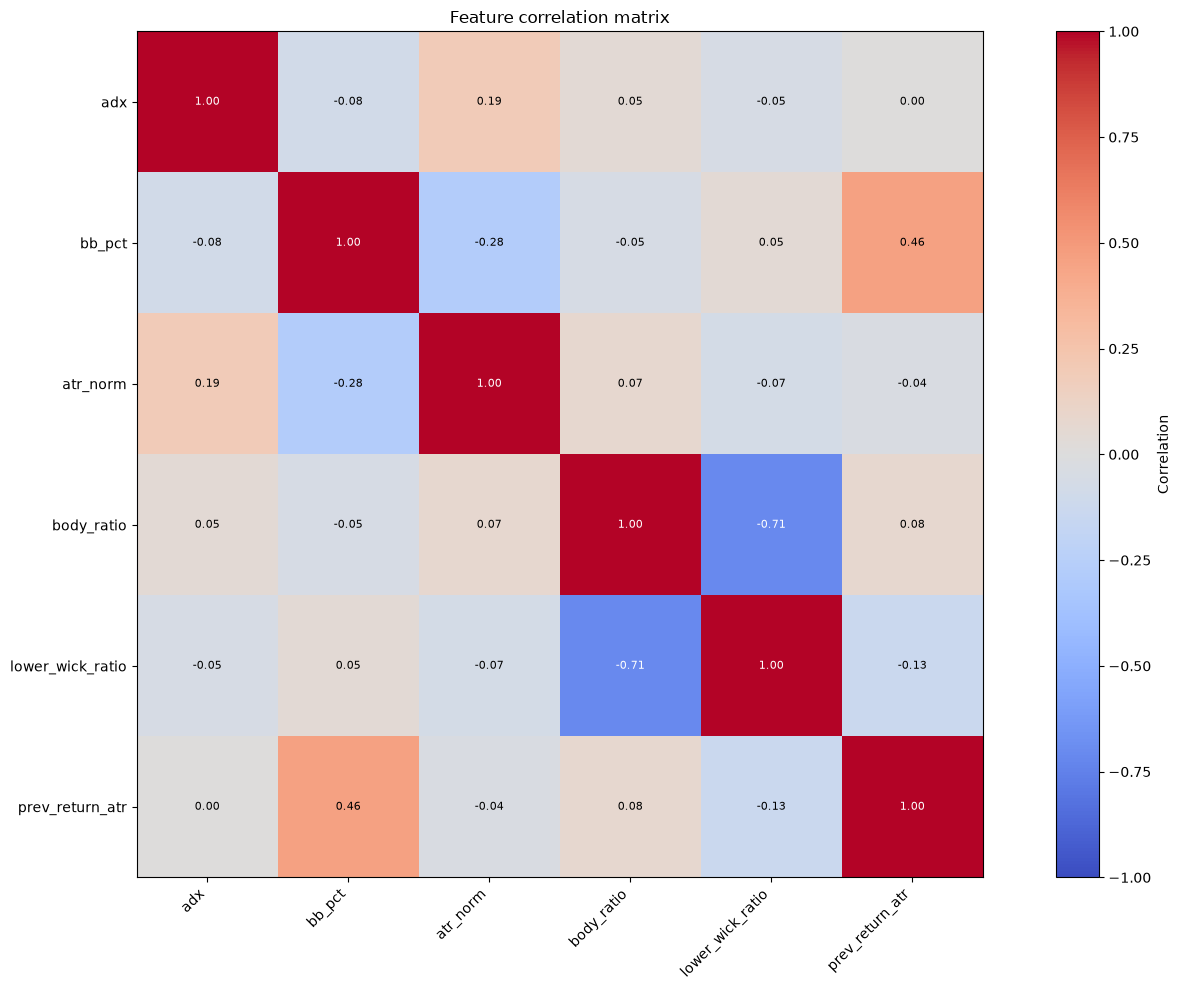

In [263]:
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(15, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols))); ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticks(range(len(feature_cols))); ax.set_yticklabels(feature_cols)
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                 color="white" if abs(val) > 0.6 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

**How to read it:** each cell is the Pearson correlation between two features, from -1 (perfectly opposite) to +1 (perfectly aligned); the diagonal is always 1 (a feature with itself). Look for any off-diagonal cell close to +1 or -1 — that's two features carrying almost the same information, and a candidate for the VIF check below to confirm.

### VIF

In [264]:
vif_check_cols = feature_cols
X_vif = sm.add_constant(df[vif_check_cols].dropna())

vif = pd.DataFrame({
    "feature": vif_check_cols,
    "VIF": [variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(f)) for f in vif_check_cols],
}).sort_values("VIF", ascending=False)

vif

,feature,VIF
4,lower_wick_ratio,2.023346
3,body_ratio,1.995875
1,bb_pct,1.397125
5,prev_return_atr,1.310434
2,atr_norm,1.130654
0,adx,1.039908


Features with high, similar VIFs are telling a version of the same story (e.g. multiple ways of measuring "how extended is the current move"). If a coefficient's sign flips under different regularization strength later in this notebook, this table is usually why.

Note: VIF here is computed with an explicit constant added to the design matrix (`sm.add_constant`) — leaving it out is a common mistake that understates collinearity for any redundancy that involves a constant offset between features.

## 4. Classification target: ATR-thresholded move

Instead of predicting the raw forward return, or just its sign, the label is defined relative to recent
volatility:

- `+1` if the forward price move is at least `x * ATR` (a real, volatility-adjusted up move)
- `-1` if it's at least `x * ATR` in the other direction
- `0` otherwise (no clear move)

The threshold is compared in **price units**, matching ATR's own units — this makes the label implicitly
volatility-adjusted: the same point move counts as decisive in a calm regime but not in a turbulent one.

In [265]:
horizon = 1           # trading days ahead
atr_multiplier = 0.1  # tune this — see the sweep in section 10 for why 0.5

forward_change = df["Close"].shift(-horizon) - df["Close"]

df["target"] = 0
df.loc[forward_change >= atr_multiplier * df["atr"], "target"] = 1
df.loc[forward_change <= -atr_multiplier * df["atr"], "target"] = -1
df.loc[forward_change.isna(), "target"] = np.nan  # last row(s): no future price defined yet

### Class balance

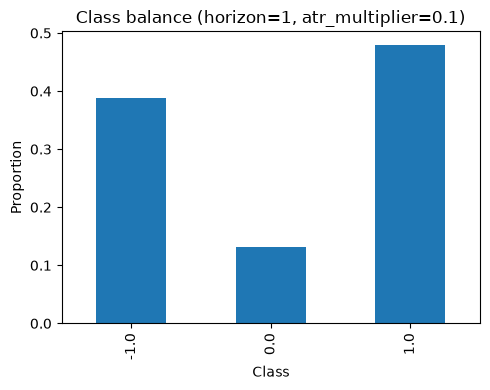

In [266]:
df["target"].value_counts(normalize=True).sort_index().plot(kind="bar", figsize=(5, 4))
plt.title(f"Class balance (horizon={horizon}, atr_multiplier={atr_multiplier})")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

Worth checking before anything else: if one class dominates, a model that mostly predicts it can look
accurate while being useless. This is why every evaluation below is checked against a naive baseline, not
accuracy alone.

## 5. Clean up

In [267]:
df = df.dropna(subset=feature_cols + ["target"])
df.shape

(2852, 12)

## 6. Three-class model

Feature matrix, chronological split, scaling fit on train only, and a multinomial logistic regression
(handled natively — no extra configuration needed for 3 classes).

In [268]:
def chrono_split_scale(X, y, split_frac=0.8):
    split_idx = int(len(X) * split_frac)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    return X_train_s, X_test_s, y_train, y_test, scaler

In [269]:
X = df[feature_cols].copy()
y = df["target"]

X_train_s, X_test_s, y_train, y_test, scaler = chrono_split_scale(X, y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

coef_df = pd.DataFrame(model.coef_.T, index=feature_cols, columns=[f"class_{c}" for c in model.classes_])
coef_df

,class_-1.0,class_0.0,class_1.0
adx,0.028129,-0.057831,0.029702
bb_pct,-0.121028,0.211781,-0.090753
atr_norm,0.002152,0.006814,-0.008967
body_ratio,-0.035691,0.064494,-0.028803
lower_wick_ratio,0.014529,0.008407,-0.022936
prev_return_atr,0.037118,0.003292,-0.040410


Each column is that feature's pull toward one class relative to the others, not a single overall effect.

In [270]:
y_pred = model.predict(X_test_s)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.5026

              precision    recall  f1-score   support

        -1.0       1.00      0.00      0.01       204
         0.0       0.00      0.00      0.00        81
         1.0       0.50      1.00      0.67       286

    accuracy                           0.50       571
   macro avg       0.50      0.33      0.23       571
weighted avg       0.61      0.50      0.34       571



**Overall accuracy is not the number that matters for trading.** Precision and recall on classes `1`
and `-1` specifically say whether the model catches real moves and how often it's wrong when it calls one.

In [271]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    n = len(labels)

    fig, ax = plt.subplots(figsize=(20, 10))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_xticklabels([str(l) for l in labels])
    ax.set_yticks(range(n)); ax.set_yticklabels([str(l) for l in labels])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 1.2 else "black")
    plt.tight_layout()
    plt.show()
    return cm

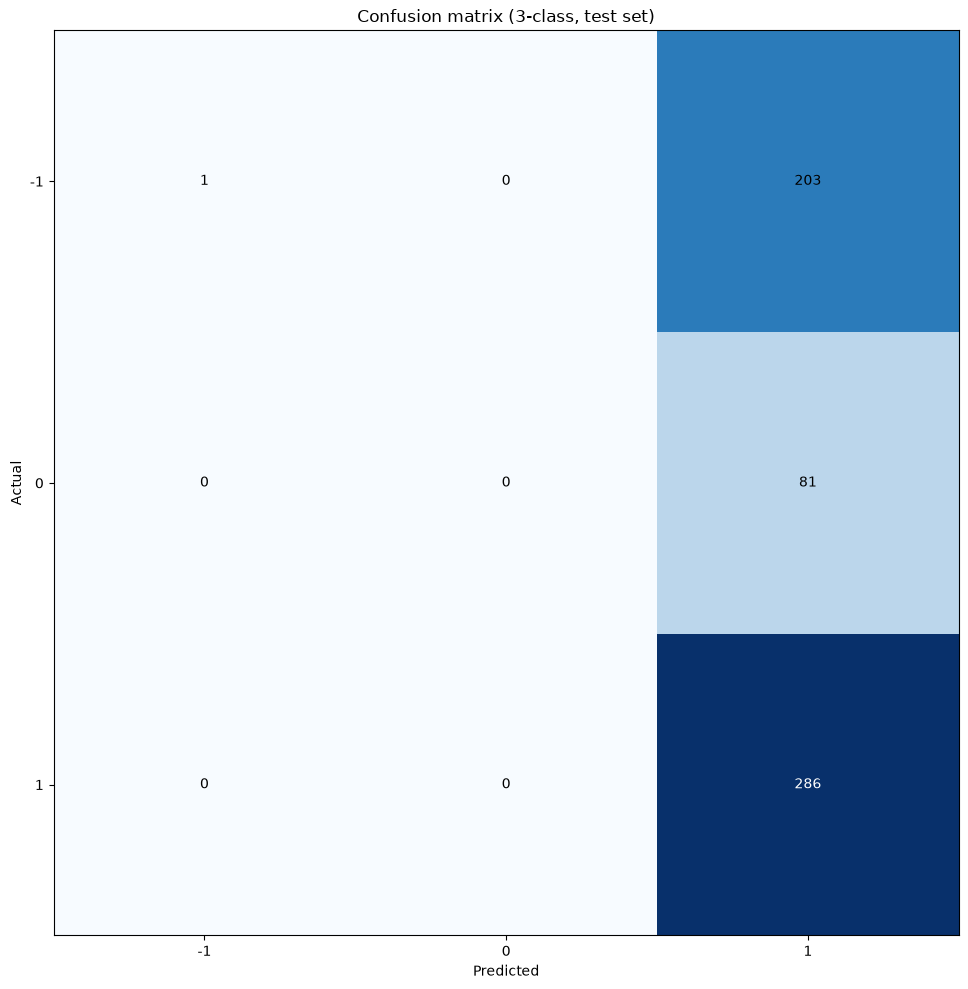

In [272]:
plot_confusion_matrix(y_test, y_pred, labels=[-1, 0, 1], title="Confusion matrix (3-class, test set)");

### Naive baseline: always predict the majority class

In [273]:
majority_class = y_train.mode()[0]
naive_pred = np.full(len(y_test), majority_class)

print(f"Majority class in training set: {majority_class}")
print(f"Model accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Naive accuracy:  {accuracy_score(y_test, naive_pred):.4f}")

Majority class in training set: 1.0
Model accuracy:  0.5026
Naive accuracy:  0.5009


If the model isn't clearly above this, it hasn't demonstrated anything beyond \"the majority class is common.\"

### Walk-forward validation

In [274]:
def evaluate_classification_walkforward(X, y, n_splits=5, class_weight=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        m = LogisticRegression(max_iter=1000, class_weight=class_weight)
        m.fit(X_tr_s, y_tr)
        pred = m.predict(X_te_s)

        maj = y_tr.mode()[0]
        naive_pred = np.full(len(y_te), maj)

        rows.append({
            "fold": i + 1,
            "test_start": X_te.index.min().date(),
            "test_end": X_te.index.max().date(),
            "accuracy": accuracy_score(y_te, pred),
            "naive_accuracy": accuracy_score(y_te, naive_pred),
        })

    return pd.DataFrame(rows)

evaluate_classification_walkforward(X, y)

,fold,test_start,test_end,accuracy,naive_accuracy
0,1,2017-02-21,2019-01-09,0.391579,0.473684
1,2,2019-01-10,2020-11-25,0.473684,0.522105
2,3,2020-11-27,2022-10-17,0.469474,0.471579
3,4,2022-10-18,2024-09-09,0.471579,0.482105
4,5,2024-09-10,2026-08-03,0.490526,0.488421


A single train/test split isn't enough to trust a result. If accuracy tracks the naive baseline
closely across every fold, that's the honest answer. If it's consistently and meaningfully ahead — fold by
fold, not just on average — that's worth building on.

## 7. Binary target: only the decisive up-move matters

`1` if the forward move clears the ATR threshold on the upside, `0` for everything else (neutral days and
decisive down-moves collapsed together) — the right shape for a long-only signal. This sharpens the class
imbalance, which changes how "accuracy" should be read from here on.

In [275]:
def build_binary_target(df, horizon, atr_multiplier):
    forward_change = df["Close"].shift(-horizon) - df["Close"]
    target = pd.Series(0.0, index=df.index)
    target[forward_change >= atr_multiplier * df["atr"]] = 1
    target[forward_change.isna()] = np.nan
    return target


def build_xy(source_df, horizon, atr_multiplier, feature_cols):
    target = build_binary_target(source_df, horizon, atr_multiplier)
    data = source_df[feature_cols].copy()
    data["target"] = target
    data = data.dropna(subset=feature_cols + ["target"])
    return data[feature_cols], data["target"]

In [276]:
X_bin, y_bin = build_xy(df, horizon, atr_multiplier, feature_cols)
y_bin.value_counts(normalize=True)

target
0.0    0.521221
1.0    0.478779
Name: proportion, dtype: float64

### Default weighting

In [277]:
X_train_bin_s, X_test_bin_s, y_train_bin, y_test_bin, scaler_bin = chrono_split_scale(X_bin, y_bin)

model_bin = LogisticRegression(max_iter=1000)
model_bin.fit(X_train_bin_s, y_train_bin)
y_pred_bin = model_bin.predict(X_test_bin_s)

majority_class_bin = y_train_bin.mode()[0]
naive_pred_bin = np.full(len(y_test_bin), majority_class_bin)

print(f"Model accuracy: {accuracy_score(y_test_bin, y_pred_bin):.4f}")
print(f"Naive accuracy (always predict {majority_class_bin}): {accuracy_score(y_test_bin, naive_pred_bin):.4f}")
print()
print(classification_report(y_test_bin, y_pred_bin, zero_division=0))

Model accuracy: 0.5201
Naive accuracy (always predict 0.0): 0.4991

              precision    recall  f1-score   support

         0.0       0.51      0.89      0.65       285
         1.0       0.58      0.15      0.24       286

    accuracy                           0.52       571
   macro avg       0.55      0.52      0.44       571
weighted avg       0.55      0.52      0.44       571



With `0` as the majority class, a model that leans toward predicting `0` can match the naive baseline
on accuracy while rarely flagging a real `1`. Check the `1` row's recall specifically.

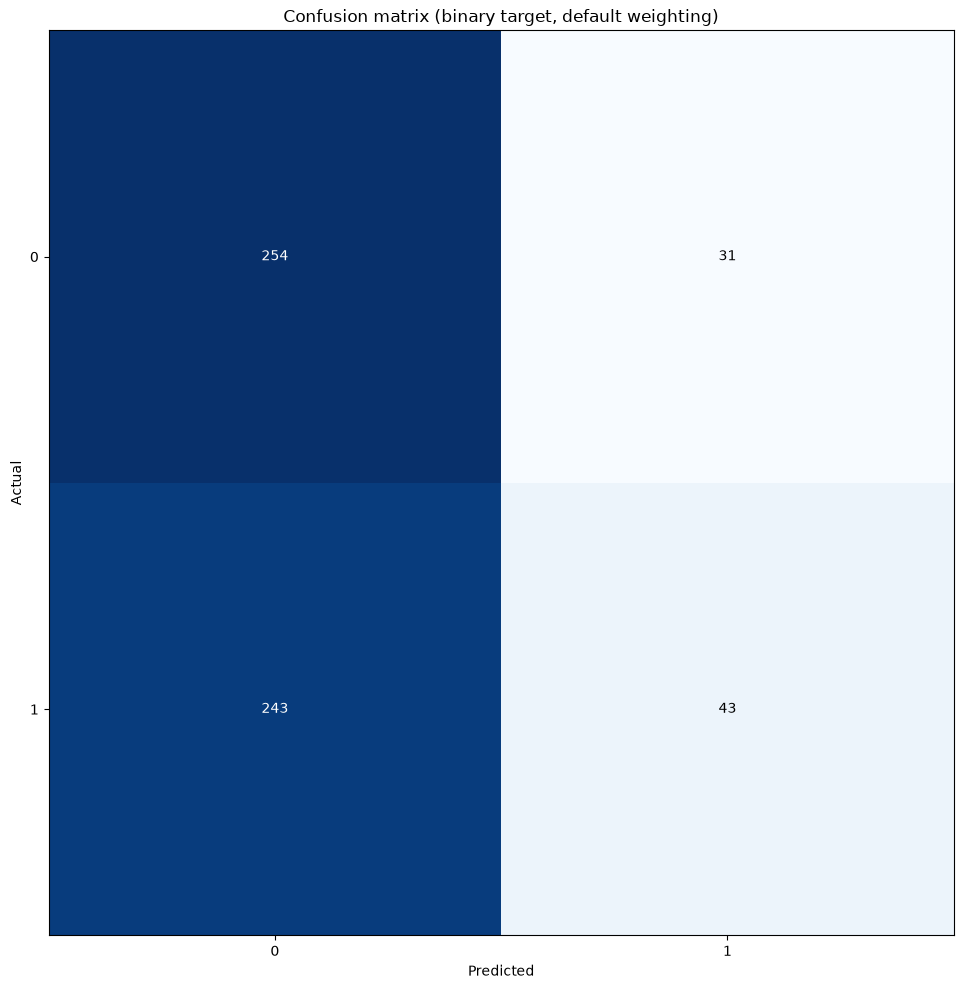

In [278]:
plot_confusion_matrix(y_test_bin, y_pred_bin, labels=[0, 1], title="Confusion matrix (binary target, default weighting)");

In [279]:
evaluate_classification_walkforward(X_bin, y_bin)

,fold,test_start,test_end,accuracy,naive_accuracy
0,1,2017-02-17,2019-01-08,0.509474,0.526316
1,2,2019-01-09,2020-11-24,0.494737,0.477895
2,3,2020-11-25,2022-10-14,0.494737,0.528421
3,4,2022-10-17,2024-09-06,0.511579,0.517895
4,5,2024-09-09,2026-07-31,0.528421,0.511579


## 8. `class_weight='balanced'`

Weighs the minority class (`1`) more heavily during fitting. Typically raises recall on `1` at the cost of
overall accuracy, since it also raises false positives. Once weighted this way, comparing accuracy to the
naive baseline stops being meaningful — precision/recall on class `1` is the honest comparison instead.

In [280]:
model_bin_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
model_bin_balanced.fit(X_train_bin_s, y_train_bin)
y_pred_bin_balanced = model_bin_balanced.predict(X_test_bin_s)

print(f"Accuracy (balanced):  {accuracy_score(y_test_bin, y_pred_bin_balanced):.4f}")
print(f"Accuracy (default):   {accuracy_score(y_test_bin, y_pred_bin):.4f}")
print()
print("Classification report (balanced):")
print(classification_report(y_test_bin, y_pred_bin_balanced, zero_division=0))

Accuracy (balanced):  0.5131
Accuracy (default):   0.5201

Classification report (balanced):
              precision    recall  f1-score   support

         0.0       0.51      0.60      0.55       285
         1.0       0.52      0.42      0.47       286

    accuracy                           0.51       571
   macro avg       0.51      0.51      0.51       571
weighted avg       0.51      0.51      0.51       571



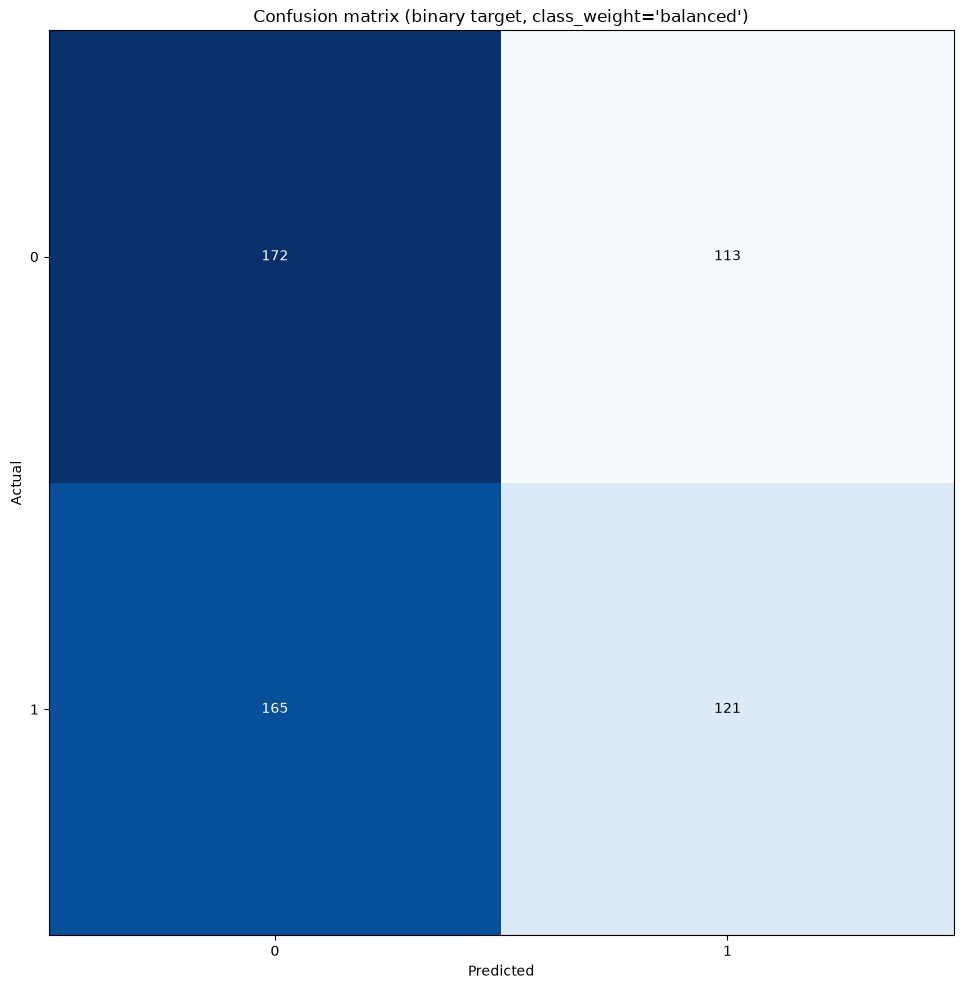

In [281]:
plot_confusion_matrix(y_test_bin, y_pred_bin_balanced, labels=[0, 1], title="Confusion matrix (binary target, class_weight='balanced')");

In [282]:
evaluate_classification_walkforward(X_bin, y_bin, class_weight="balanced")

,fold,test_start,test_end,accuracy,naive_accuracy
0,1,2017-02-17,2019-01-08,0.498947,0.526316
1,2,2019-01-09,2020-11-24,0.498947,0.477895
2,3,2020-11-25,2022-10-14,0.473684,0.528421
3,4,2022-10-17,2024-09-06,0.513684,0.517895
4,5,2024-09-09,2026-07-31,0.511579,0.511579


## 9. The metric that actually settles it: precision vs. base rate, per fold

Accuracy vs. the naive baseline isn't a fair comparison once the model is class-weighted — the naive
baseline tends to win on raw accuracy almost by construction. What matters is whether **precision on class
1** beats its own base rate consistently, fold by fold, not on average.

A random signal with no edge would still show `precision_class1` roughly equal to the base rate of class `1`
in that fold — so the bar is "precision meaningfully above the base rate, consistently," not "precision above
zero."

In [283]:
def evaluate_classification_walkforward_detailed(X, y, n_splits=5, class_weight=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        m = LogisticRegression(max_iter=1000, class_weight=class_weight)
        m.fit(X_tr_s, y_tr)
        pred = m.predict(X_te_s)

        maj = y_tr.mode()[0]
        naive_pred = np.full(len(y_te), maj)

        rows.append({
            "fold": i + 1,
            "test_start": X_te.index.min().date(),
            "test_end": X_te.index.max().date(),
            "accuracy": accuracy_score(y_te, pred),
            "naive_accuracy": accuracy_score(y_te, naive_pred),
            "test_base_rate_class1": y_te.mean(),
            "precision_class1": precision_score(y_te, pred, pos_label=1, zero_division=0),
            "recall_class1": recall_score(y_te, pred, pos_label=1, zero_division=0),
            "precision_lift_vs_base_rate": precision_score(y_te, pred, pos_label=1, zero_division=0) - y_te.mean(),
        })

    return pd.DataFrame(rows)

evaluate_classification_walkforward_detailed(X_bin, y_bin, class_weight="balanced")

,fold,test_start,test_end,accuracy,naive_accuracy,test_base_rate_class1,precision_class1,recall_class1,precision_lift_vs_base_rate
0,1,2017-02-17,2019-01-08,0.498947,0.526316,0.473684,0.470588,0.462222,-0.003096
1,2,2019-01-09,2020-11-24,0.498947,0.477895,0.522105,0.543103,0.254032,0.020998
2,3,2020-11-25,2022-10-14,0.473684,0.528421,0.471579,0.443966,0.459821,-0.027613
3,4,2022-10-17,2024-09-06,0.513684,0.517895,0.482105,0.494382,0.384279,0.012277
4,5,2024-09-09,2026-07-31,0.511579,0.511579,0.488421,0.500000,0.439655,0.011579


## 10. Sweeping the ATR threshold

Does the threshold itself matter? `atr_multiplier = 0` is the loosest possible definition — any positive
move counts, which is just the sign of the next-day return. Higher multipliers demand a more decisive move,
trading data quantity for label quality.

One detail: `forward_change` is undefined for the last `horizon` row(s), and a plain threshold comparison
against `NaN` silently evaluates to `False` instead of propagating — the helper below excludes those rows
explicitly.

In [284]:
atr_multipliers_to_test = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_rows = []

for mult in atr_multipliers_to_test:
    X_sweep, y_sweep = build_xy(df, horizon, mult, feature_cols)

    fold_results = evaluate_classification_walkforward_detailed(X_sweep, y_sweep, class_weight="balanced")
    lift = fold_results["precision_lift_vs_base_rate"]

    sweep_rows.append({
        "atr_multiplier": mult,
        "class1_rate": y_sweep.mean(),
        "mean_accuracy": fold_results["accuracy"].mean(),
        "mean_naive_accuracy": fold_results["naive_accuracy"].mean(),
        "mean_precision_lift": lift.mean(),
        "std_precision_lift": lift.std(),
        "mean_recall_class1": fold_results["recall_class1"].mean(),
    })

sweep_summary = pd.DataFrame(sweep_rows)
sweep_summary["lift_over_std"] = sweep_summary["mean_precision_lift"] / sweep_summary["std_precision_lift"]
sweep_summary

,atr_multiplier,class1_rate,mean_accuracy,mean_naive_accuracy,mean_precision_lift,std_precision_lift,mean_recall_class1,lift_over_std
0,0.0,0.544020,0.486316,0.549895,-0.001162,0.030327,0.409477,-0.038331
1,0.1,0.478779,0.499368,0.512421,0.002829,0.019090,0.400002,0.148184
2,0.2,0.421256,0.521263,0.574316,0.016362,0.025699,0.406929,0.636676
3,0.3,0.357418,0.551158,0.636632,0.038727,0.028488,0.432011,1.359397
4,0.4,0.306910,0.578526,0.688421,0.055882,0.034226,0.446392,1.632719
5,0.5,0.261312,0.614316,0.735579,0.070620,0.021521,0.450403,3.281492
6,0.6,0.225535,0.632842,0.770105,0.071650,0.037105,0.437179,1.931024
7,0.7,0.186952,0.646737,0.810526,0.066896,0.037564,0.447279,1.780851
8,0.8,0.149421,0.661474,0.852211,0.058679,0.033141,0.464461,1.770581
9,0.9,0.116450,0.679158,0.884211,0.059888,0.019211,0.484057,3.117386


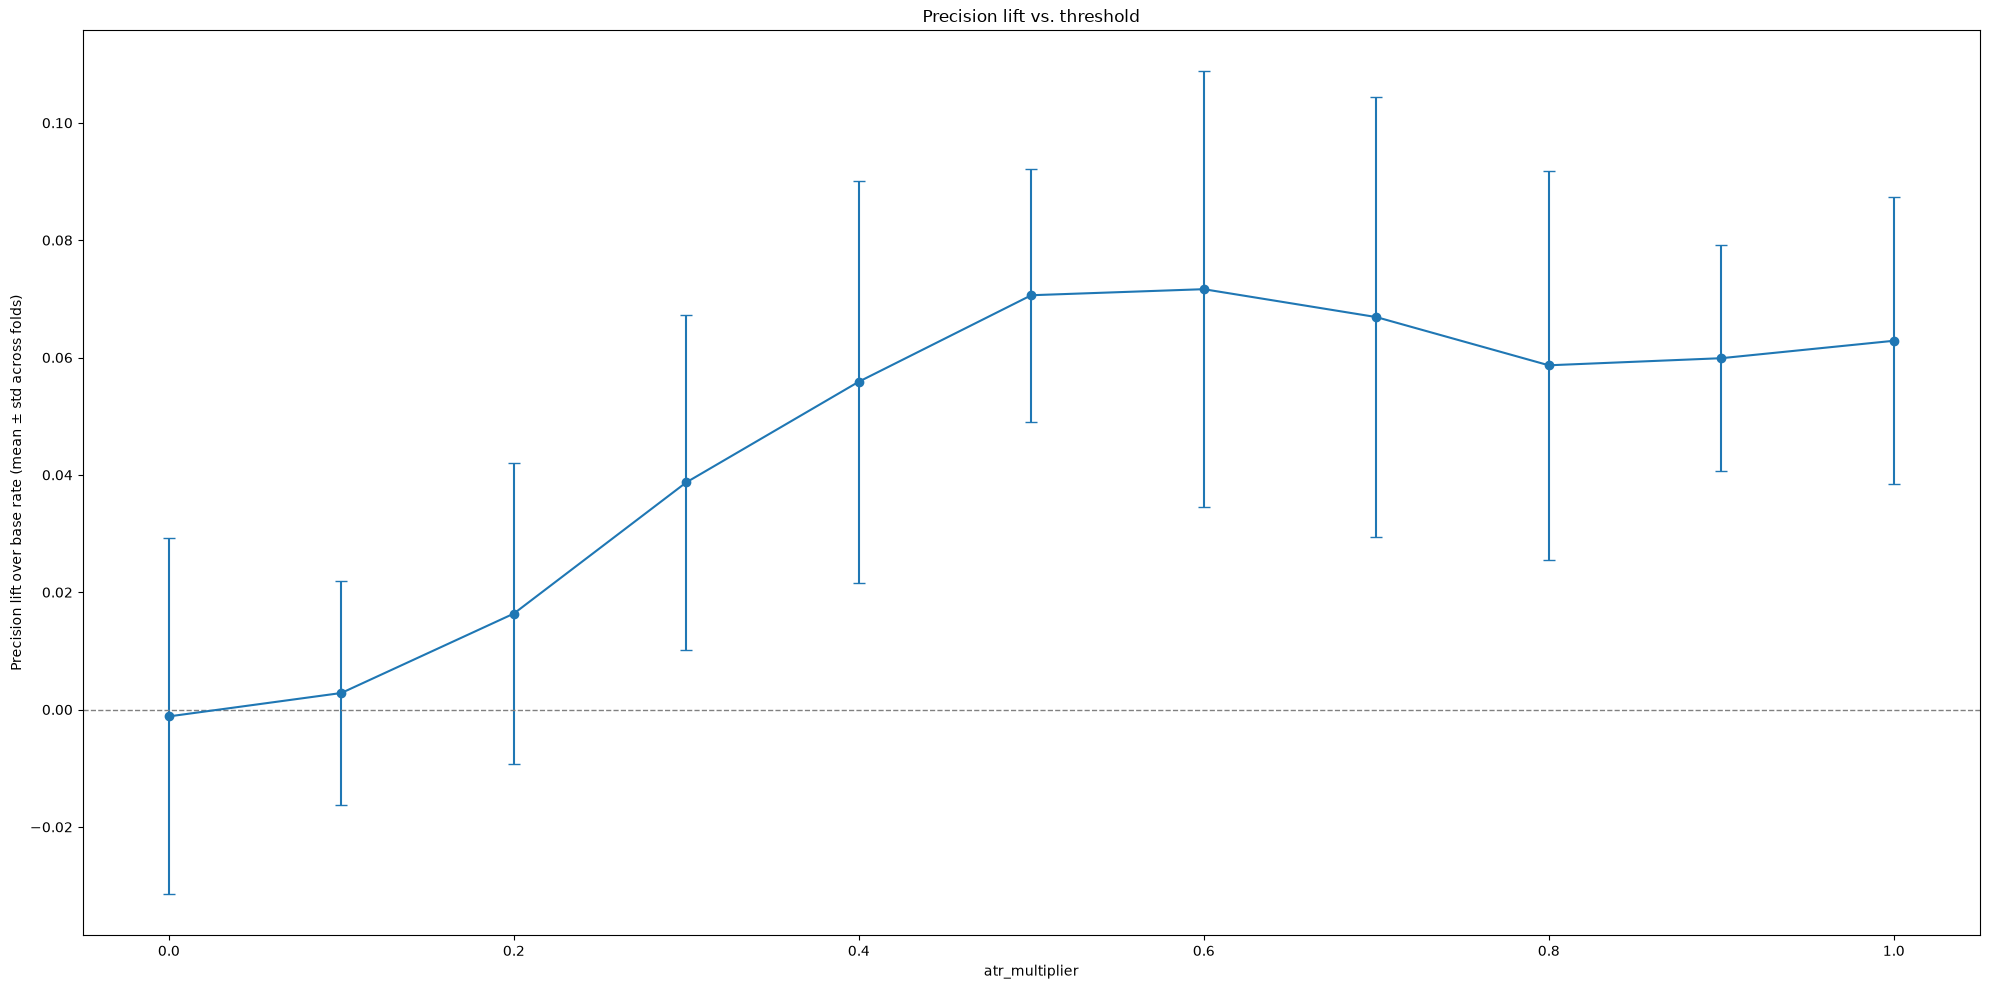

In [295]:
plt.figure(figsize=(20, 10))
plt.errorbar(
    sweep_summary["atr_multiplier"], sweep_summary["mean_precision_lift"],
    yerr=sweep_summary["std_precision_lift"], marker="o", capsize=4,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("atr_multiplier")
plt.ylabel("Precision lift over base rate (mean ± std across folds)")
plt.title("Precision lift vs. threshold")
plt.tight_layout()
plt.show()

The error bars are the fold-to-fold standard deviation, not a formal confidence interval, but serve
the same purpose: if a bar comfortably straddles zero, that threshold isn't giving a reliable edge, only an
occasionally positive one. A real, exploitable threshold shows mean lift clearly above zero **and** error
bars that stay mostly above zero too — consistency, not just a good average.

## 11. Validating the sweep before trusting it

From roughly `atr_multiplier = 0.3` onward the lift isn't just occasionally positive, it climbs in an
orderly way and stays above its own fold-to-fold variability — different from a single good number, which is
easy to get by chance. Two things worth checking before treating this as settled: whether each precision
number rests on enough predictions to be meaningful, and whether the pattern survives more, smaller folds.

In [286]:
def walkforward_raw_counts(X, y, n_splits=5, class_weight=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        m = LogisticRegression(max_iter=1000, class_weight=class_weight)
        m.fit(X_tr_s, y_tr)
        pred = m.predict(X_te_s)

        cm = confusion_matrix(y_te, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        rows.append({
            "fold": i + 1,
            "n_test": len(y_te),
            "n_actual_pos": int(y_te.sum()),
            "n_predicted_pos": tp + fp,
            "tp": tp, "fp": fp,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
            "recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        })

    return pd.DataFrame(rows)


for mult in [0.5, 0.7]:
    X_check, y_check = build_xy(df, horizon, mult, feature_cols)

    print(f"=== atr_multiplier = {mult} ===")
    display(walkforward_raw_counts(X_check, y_check, n_splits=5, class_weight="balanced"))

=== atr_multiplier = 0.5 ===


,fold,n_test,n_actual_pos,n_predicted_pos,tp,fp,precision,recall
0,1,475,114,173,50,123,0.289017,0.438596
1,2,475,139,116,45,71,0.387931,0.323741
2,3,475,122,207,65,142,0.314010,0.532787
3,4,475,131,185,62,123,0.335135,0.473282
4,5,475,122,169,59,110,0.349112,0.483607


=== atr_multiplier = 0.7 ===


,fold,n_test,n_actual_pos,n_predicted_pos,tp,fp,precision,recall
0,1,475,86,159,32,127,0.201258,0.372093
1,2,475,88,101,30,71,0.297030,0.340909
2,3,475,96,186,55,131,0.295699,0.572917
3,4,475,105,184,48,136,0.260870,0.457143
4,5,475,75,163,37,126,0.226994,0.493333


If `n_predicted_pos` and `tp` are in the tens or low hundreds in every fold, precision isn't a small-sample fluke.

In [287]:
for mult in [0.3, 0.5, 0.7, 0.9]:
    X_check, y_check = build_xy(df, horizon, mult, feature_cols)

    fold_results = evaluate_classification_walkforward_detailed(X_check, y_check, n_splits=10, class_weight="balanced")
    lift = fold_results["precision_lift_vs_base_rate"]
    print(f"atr_multiplier={mult}: mean_lift={lift.mean():.4f}  std_lift={lift.std():.4f}  "
          f"positive_folds={sum(lift > 0)}/10")

atr_multiplier=0.3: mean_lift=0.0485  std_lift=0.0388  positive_folds=9/10
atr_multiplier=0.5: mean_lift=0.0811  std_lift=0.0463  positive_folds=10/10
atr_multiplier=0.7: mean_lift=0.0796  std_lift=0.0493  positive_folds=10/10
atr_multiplier=0.9: mean_lift=0.0627  std_lift=0.0247  positive_folds=10/10


`positive_folds` out of 10 is the key number here, not just the mean. One honest caveat: re-running
this same check on pure-noise data can occasionally also show `10/10` by chance with only 10 folds — the
fold-consistency count is supporting evidence, not proof by itself. What makes a result more credible is the
*combination* of high fold consistency **and** a lift magnitude that grows in an orderly way as the
threshold rises, rather than either signal alone.

## 12. Coefficients at the strongest threshold

Fit on the full available sample (not train/test) purely to read the coefficients — this cell is for
interpretation, not another performance number. Check whether the sign pattern tells a coherent story
(e.g. trend/momentum features pushing one way, overbought/extended features pushing the other) rather than
weight landing on an arbitrary feature.

In [288]:
X_check, y_check = build_xy(df, horizon, 0.5, feature_cols)

scaler_check = StandardScaler()
X_check_s = scaler_check.fit_transform(X_check)

model_check = LogisticRegression(max_iter=1000, class_weight="balanced")
model_check.fit(X_check_s, y_check)

coef_check = pd.Series(model_check.coef_[0], index=feature_cols).sort_values()
coef_check

bb_pct             -0.331250
atr_norm           -0.058900
body_ratio         -0.049034
prev_return_atr    -0.047964
lower_wick_ratio    0.042486
adx                 0.113546
dtype: float64

This set was already pruned for collinearity (section 3), so coefficients here should be more stable than
with the full original feature list — but a couple of features still sit in the VIF 5-9 range, so signs and
magnitudes can still shift somewhat under different regularization strength. Section 15 checks this
directly.

## 13. Does the same pattern show up on other instruments?

If threshold-scaling precision lift is a general phenomenon rather than one instrument's coincidence, it
should replicate at least partially elsewhere. It doesn't need to replicate identically — different
instruments can have different dynamics — but a pattern that shows up *only* on one instrument after a lot of
iterative testing is a reason for caution rather than confidence.

In [289]:
replication_instruments = {
    "EURUSD=X": "FX",
    "GC=F": "Metal (gold)",
    "AAPL": "Equity (single stock)",
}

replication_rows = []

for rep_ticker, asset_class in replication_instruments.items():
    raw = download(rep_ticker)
    d = build_features(raw)

    for mult in [0.3, 0.5, 0.7]:
        X_rep, y_rep = build_xy(d, horizon, mult, feature_cols)

        if len(X_rep) < 300:
            continue

        fold_results = evaluate_classification_walkforward_detailed(X_rep, y_rep, n_splits=10, class_weight="balanced")
        lift = fold_results["precision_lift_vs_base_rate"]

        replication_rows.append({
            "ticker": rep_ticker,
            "asset_class": asset_class,
            "atr_multiplier": mult,
            "mean_lift": lift.mean(),
            "positive_folds": int((lift > 0).sum()),
        })

pd.DataFrame(replication_rows)

,ticker,asset_class,atr_multiplier,mean_lift,positive_folds
0,EURUSD=X,FX,0.3,0.309234,10
1,EURUSD=X,FX,0.5,0.249095,10
2,EURUSD=X,FX,0.7,0.160216,10
3,GC=F,Metal (gold),0.3,0.022093,8
4,GC=F,Metal (gold),0.5,0.028099,7
5,GC=F,Metal (gold),0.7,0.023621,7
6,AAPL,Equity (single stock),0.3,0.004824,5
7,AAPL,Equity (single stock),0.5,0.009357,4
8,AAPL,Equity (single stock),0.7,0.012062,7


If every other instrument sits flat near zero at every threshold while only the original one shows
this, that points at something instrument- or period-specific rather than a general property. If a couple of
the others show a similar rising pattern, that's the strongest form of evidence in this notebook.

## 14. Data-quality check

An unusually large lift on one instrument is worth a sanity check against feed artifacts before trusting it
— particularly for FX data, which is often an indicative feed rather than exchange-traded and can carry
stale weekend bars or a mechanically-repeated `Open`. Three checks, benchmarked against the original
instrument as a "clean data" reference: zero-range days, `Open` equal to the prior `Close`, and duplicate
`Close` values.

In [290]:
def data_quality_report(raw, name):
    zero_range = (raw["High"] == raw["Low"]).sum()
    open_eq_prev_close = (raw["Open"] == raw["Close"].shift(1)).sum()
    duplicate_close = raw["Close"].duplicated().sum()
    expected_bdays = len(pd.bdate_range(raw.index.min(), raw.index.max()))
    actual_rows = len(raw)

    print(f"--- {name} ---")
    print(f"Rows: {actual_rows}  (expected ~{expected_bdays} business days, gap: {expected_bdays - actual_rows})")
    print(f"Zero-range (High == Low) days: {zero_range} ({zero_range/actual_rows:.2%})")
    print(f"Open == previous Close: {open_eq_prev_close} ({open_eq_prev_close/actual_rows:.2%})")
    print(f"Duplicate Close values: {duplicate_close} ({duplicate_close/actual_rows:.2%})")
    print()


raw_eurusd = download("EURUSD=X")
raw_reference = download(ticker)

data_quality_report(raw_eurusd, "EUR/USD")
data_quality_report(raw_reference, f"{ticker} (reference)")

--- EUR/USD ---
Rows: 3016  (expected ~3024 business days, gap: 8)
Zero-range (High == Low) days: 1 (0.03%)
Open == previous Close: 4 (0.13%)
Duplicate Close values: 405 (13.43%)

--- ^GSPC (reference) ---
Rows: 2913  (expected ~3023 business days, gap: 110)
Zero-range (High == Low) days: 0 (0.00%)
Open == previous Close: 1 (0.03%)
Duplicate Close values: 12 (0.41%)



A high `Open == previous Close` or zero-range rate would point at stale/low-quality bars. A high
duplicate-`Close` rate is ambiguous on its own — it can mean the same thing, or it can just reflect a
narrower absolute price range with limited decimal precision (more numerical collisions by chance, nothing
to do with data quality). The gap-distance check below tells them apart.

In [291]:
def duplicate_gap_analysis(raw, name):
    close = raw["Close"]
    dup_mask = close.duplicated(keep=False)

    gaps = []
    for val, group in close[dup_mask].groupby(close[dup_mask]):
        positions = [close.index.get_loc(i) for i in group.index]
        positions.sort()
        gaps.extend(np.diff(positions))
    gaps = np.array(gaps)

    print(f"--- {name} ---")
    if len(gaps) > 0:
        print(f"duplicate pairs: {len(gaps)}")
        print(f"gap (trading days) — median: {np.median(gaps):.0f}, mean: {gaps.mean():.1f}")
        print(f"% of pairs within 3 trading days of each other: {(gaps <= 3).mean():.1%}")
        print(f"% of pairs more than 30 trading days apart: {(gaps > 30).mean():.1%}")
    else:
        print("no duplicates found")
    print()


duplicate_gap_analysis(raw_eurusd, "EUR/USD")
duplicate_gap_analysis(raw_reference, f"{ticker} (reference)")

--- EUR/USD ---
duplicate pairs: 405
gap (trading days) — median: 359, mean: 689.4
% of pairs within 3 trading days of each other: 4.7%
% of pairs more than 30 trading days apart: 83.5%

--- ^GSPC (reference) ---
duplicate pairs: 12
gap (trading days) — median: 32, mean: 82.7
% of pairs within 3 trading days of each other: 8.3%
% of pairs more than 30 trading days apart: 50.0%



Duplicates clustered within a few trading days point at real stale bars — worth investigating further,
possibly with a different data source, before trusting that instrument's result. Duplicates scattered months
or years apart are consistent with the benign rounding/narrow-range explanation.

## 15. Regularization

`LogisticRegression` regularizes by default (L2, `C=1.0`). Worth testing L1 specifically here given the
collinearity already flagged in section 3 — if L1 zeroes out redundant features while keeping the same
overall sign pattern on the survivors, that supports the result being real rather than spread across
overlapping features. In this scikit-learn version, `penalty` is deprecated in favor of `l1_ratio`
(`0.0` → pure L2, `1.0` → pure L1). L1 and Elastic Net require `solver="saga"`.

### L2 vs. L1, side by side

In [292]:
X_reg, y_reg = build_xy(df, horizon, 0.5, feature_cols)

X_train_reg_s, X_test_reg_s, y_train_reg, y_test_reg, scaler_reg = chrono_split_scale(X_reg, y_reg)

model_l2 = LogisticRegression(l1_ratio=0.0, C=1.0, max_iter=1000, class_weight="balanced")
model_l2.fit(X_train_reg_s, y_train_reg)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_l1 = LogisticRegression(l1_ratio=1.0, C=1.0, solver="saga", max_iter=5000, class_weight="balanced")
    model_l1.fit(X_train_reg_s, y_train_reg)

coef_compare = pd.DataFrame({
    "L2": model_l2.coef_[0],
    "L1": model_l1.coef_[0],
}, index=feature_cols).sort_values("L2")

coef_compare

,L2,L1
bb_pct,-0.321764,-0.320313
atr_norm,-0.043455,-0.041086
prev_return_atr,-0.041184,-0.040113
body_ratio,-0.038340,-0.037337
lower_wick_ratio,0.017980,0.017014
adx,0.115007,0.113036


Features L1 zeroes out entirely are the ones it judged redundant given the others already in the model.

### Tuning C and l1_ratio with time-respecting cross-validation

`LogisticRegressionCV`'s default scoring is plain accuracy, which doesn't account for `class_weight`. On
imbalanced data this can pick the most aggressive regularization possible (every coefficient shrunk to `0`)
because a model that predicts almost nothing but the majority class scores well on raw accuracy while being
useless for catching class `1`. This isn't a one-off — it reproduces reliably whenever the true signal is
weak-to-moderate relative to the imbalance. The fix: score the search on the same metric used everywhere else
in this notebook — precision lift over the base rate — instead of accuracy.

In [293]:
def precision_lift_score(y_true, y_pred):
    base_rate = np.mean(y_true)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    return prec - base_rate

precision_lift_scorer = make_scorer(precision_lift_score)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_cv = LogisticRegressionCV(
        Cs=10,
        l1_ratios=[0.0, 0.25, 0.5, 0.75, 1.0],
        cv=TimeSeriesSplit(n_splits=5),
        solver="saga",
        max_iter=5000,
        class_weight="balanced",
        scoring=precision_lift_scorer,
        n_jobs=-1,
    )
    model_cv.fit(X_train_reg_s, y_train_reg)

print(f"Best C: {model_cv.C_[0]:.4g}")
print(f"Best l1_ratio: {model_cv.l1_ratio_[0]:.2f}")

coef_cv = pd.Series(model_cv.coef_[0], index=feature_cols).sort_values()
coef_cv

Best C: 0.0007743
Best l1_ratio: 0.00


bb_pct             -0.095344
prev_return_atr    -0.043584
body_ratio         -0.009584
lower_wick_ratio    0.007866
atr_norm            0.009091
adx                 0.036726
dtype: float64

### Does regularization change the walk-forward result?

In [294]:
def evaluate_classification_walkforward_regularized(X, y, n_splits=5, l1_ratio=0.0, C=1.0, solver="lbfgs", class_weight=None):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)

        m = LogisticRegression(l1_ratio=l1_ratio, C=C, solver=solver, max_iter=5000, class_weight=class_weight)
        m.fit(X_tr_s, y_tr)
        pred = m.predict(X_te_s)

        rows.append({
            "fold": i + 1,
            "precision_lift_vs_base_rate": precision_score(y_te, pred, pos_label=1, zero_division=0) - y_te.mean(),
        })

    return pd.DataFrame(rows)


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lift_l2 = evaluate_classification_walkforward_regularized(
        X_reg, y_reg, l1_ratio=0.0, C=1.0, solver="lbfgs", class_weight="balanced"
    )["precision_lift_vs_base_rate"]

    lift_l1 = evaluate_classification_walkforward_regularized(
        X_reg, y_reg, l1_ratio=1.0, C=1.0, solver="saga", class_weight="balanced"
    )["precision_lift_vs_base_rate"]

    lift_cv = evaluate_classification_walkforward_regularized(
        X_reg, y_reg, l1_ratio=float(model_cv.l1_ratio_[0]), C=float(model_cv.C_[0]),
        solver="saga", class_weight="balanced"
    )["precision_lift_vs_base_rate"]

pd.DataFrame({
    "mean_lift": [lift_l2.mean(), lift_l1.mean(), lift_cv.mean()],
    "std_lift": [lift_l2.std(), lift_l1.std(), lift_cv.std()],
    "positive_folds": [int((lift_l2 > 0).sum()), int((lift_l1 > 0).sum()), int((lift_cv > 0).sum())],
}, index=["L2 (C=1.0)", "L1 (C=1.0)", f"CV-tuned (C={model_cv.C_[0]:.3g}, l1_ratio={model_cv.l1_ratio_[0]:.2f})"])

,mean_lift,std_lift,positive_folds
L2 (C=1.0),0.070620,0.021521,5
L1 (C=1.0),0.073350,0.019890,5
"CV-tuned (C=0.000774, l1_ratio=0.00)",0.064127,0.017717,5


If all three rows land in a similar place, the predictive signal is robust to the regularization
choice — even if the specific coefficient values (and therefore which feature "explains" the result) shift
between them. That combination — stable performance, unstable attribution — is common with correlated
features (section 3) and is a more honest reading than picking whichever fit gives the cleanest-looking
coefficient story.